# Loan Default Prediction - Exploratory Data Analysis
## Prerna Jeet
This notebook covers comprehensive EDA for the Loan Default Prediction dataset.

## 0. Setup & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

sns.set_palette('husl')

df_raw = pd.read_csv('data/dataset.csv', low_memory=False)


NUMERIC_COLS = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days', 'Employed_Days',
    'Registration_Days', 'ID_Days', 'Own_House_Age', 'Population_Region_Relative',
    'Score_Source_1', 'Score_Source_2', 'Score_Source_3',
    'Social_Circle_Default', 'Phone_Change', 'Credit_Bureau',
    'Child_Count', 'Client_Family_Members', 'Cleint_City_Rating',
    'Application_Process_Hour', 'Application_Process_Day',
    'Car_Owned', 'Bike_Owned', 'Active_Loan', 'House_Own',
    'Mobile_Tag', 'Homephone_Tag', 'Workphone_Working', 'Default',
]
df = df_raw.copy()
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (121856, 40)
Columns: ['ID', 'Client_Income', 'Car_Owned', 'Bike_Owned', 'Active_Loan', 'House_Own', 'Child_Count', 'Credit_Amount', 'Loan_Annuity', 'Accompany_Client', 'Client_Income_Type', 'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type', 'Population_Region_Relative', 'Age_Days', 'Employed_Days', 'Registration_Days', 'ID_Days', 'Own_House_Age', 'Mobile_Tag', 'Homephone_Tag', 'Workphone_Working', 'Client_Occupation', 'Client_Family_Members', 'Cleint_City_Rating', 'Application_Process_Day', 'Application_Process_Hour', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 'Type_Organization', 'Score_Source_1', 'Score_Source_2', 'Score_Source_3', 'Social_Circle_Default', 'Phone_Change', 'Credit_Bureau', 'Default']


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750.0,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250.0,1.0,0.0,1.0,NaN,0.0,15282.00,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000.0,0.0,0.0,1.0,0.0,1.0,59527.35,2788.20,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655,0.0742,277.0,0.0,0
3,12188929,15750.0,0.0,0.0,1.0,1.0,0.0,53870.40,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631355,NaN,1700.0,3.0,0
4,12133385,33750.0,1.0,0.0,1.0,0.0,2.0,133988.40,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355639,0.2021,674.0,1.0,0


## 1. Dataset Overview

In [15]:
print('=== Dataset Info ===')
df.info()
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121856 entries, 0 to 121855
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          121856 non-null  int64  
 1   Client_Income               118234 non-null  float64
 2   Car_Owned                   118275 non-null  float64
 3   Bike_Owned                  118232 non-null  float64
 4   Active_Loan                 118221 non-null  float64
 5   House_Own                   118195 non-null  float64
 6   Child_Count                 118218 non-null  float64
 7   Credit_Amount               118219 non-null  float64
 8   Loan_Annuity                117030 non-null  float64
 9   Accompany_Client            120110 non-null  object 
 10  Client_Income_Type          118155 non-null  object 
 11  Client_Education            118211 non-null  object 
 12  Client_Marital_Status       118383 non-null  object

,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Population_Region_Relative,...,Cleint_City_Rating,Application_Process_Day,Application_Process_Hour,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
count,1.218560e+05,1.182340e+05,118275.000000,118232.000000,118221.000000,118195.000000,118218.000000,118219.000000,117030.000000,116988.000000,...,119447.000000,119428.000000,118193.000000,53021.000000,116170.000000,94934.000000,59928.000000,118192.000000,103316.000000,121856.000000
mean,1.216093e+07,1.686519e+04,0.342854,0.332262,0.499175,0.692060,0.417779,60046.488951,2721.254492,0.022602,...,2.030038,3.159736,12.063100,0.501213,0.518625,0.511180,0.117428,962.106056,1.891082,0.080792
std,3.517694e+04,1.153815e+04,0.474665,0.471026,0.500001,0.461644,0.728802,40350.663346,1461.466162,0.413617,...,0.504407,1.759045,3.280695,0.211204,0.740248,0.194333,0.107974,827.976726,1.861921,0.272517
min,1.210000e+07,2.565000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,4500.000000,217.350000,0.000533,...,1.000000,0.000000,0.000000,0.014568,0.000005,0.000527,0.000000,0.000000,0.000000,0.000000
25%,1.213046e+07,1.125000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,27000.000000,1657.350000,0.010006,...,2.000000,2.000000,10.000000,0.333481,0.390164,0.372334,0.057700,272.000000,0.000000,0.000000
50%,1.216093e+07,1.440000e+04,0.000000,0.000000,0.000000,1.000000,0.000000,51750.000000,2499.750000,0.018850,...,2.000000,3.000000,12.000000,0.504657,0.564978,0.537070,0.088700,755.000000,1.000000,0.000000
75%,1.219139e+07,2.025000e+04,1.000000,1.000000,1.000000,1.000000,1.000000,80865.000000,3466.800000,0.028663,...,2.000000,5.000000,14.000000,0.673890,0.664011,0.667458,0.148500,1570.000000,3.000000,0.000000
max,1.222186e+07,1.800009e+06,1.000000,1.000000,1.000000,1.000000,19.000000,405000.000000,22500.000000,100.000000,...,3.000000,6.000000,23.000000,0.945741,100.000000,0.896010,1.000000,4185.000000,22.000000,1.000000


=== Missing Values ===
                            Missing Count  Missing %
Own_House_Age                       80095  65.729221
Score_Source_1                      68835  56.488806
Social_Circle_Default               61928  50.820641
Client_Occupation                   41435  34.003250
Score_Source_3                      26922  22.093290
Credit_Bureau                       18540  15.214680
ID_Days                              5985   4.911535
Score_Source_2                       5686   4.666163
Population_Region_Relative           4868   3.994879
Loan_Annuity                         4826   3.960412
Client_Income_Type                   3701   3.037191
Client_Housing_Type                  3687   3.025702
Employed_Days                        3666   3.008469
Phone_Change                         3664   3.006828
Application_Process_Hour             3663   3.006007
House_Own                            3661   3.004366
Loan_Contract_Type                   3651   2.996159
Client_Education       

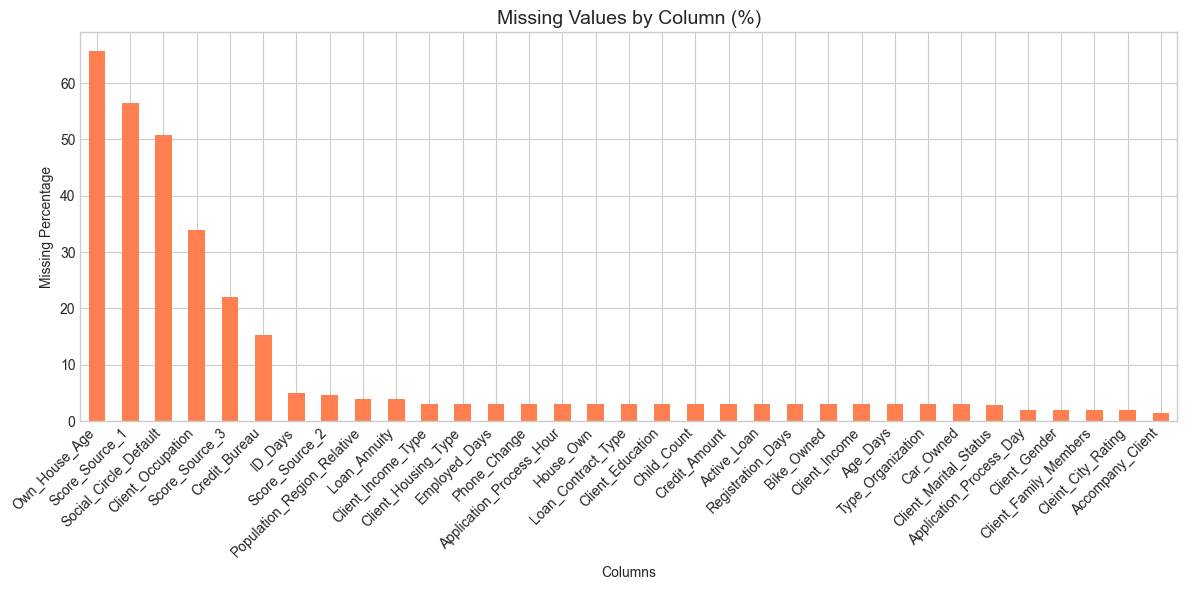

In [16]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

plt.figure(figsize=(12, 6))
missing_df['Missing %'].plot(kind='bar', color='coral')
plt.title('Missing Values by Column (%)', fontsize=14)
plt.xlabel('Columns')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Target Variable — Class Imbalance Analysis

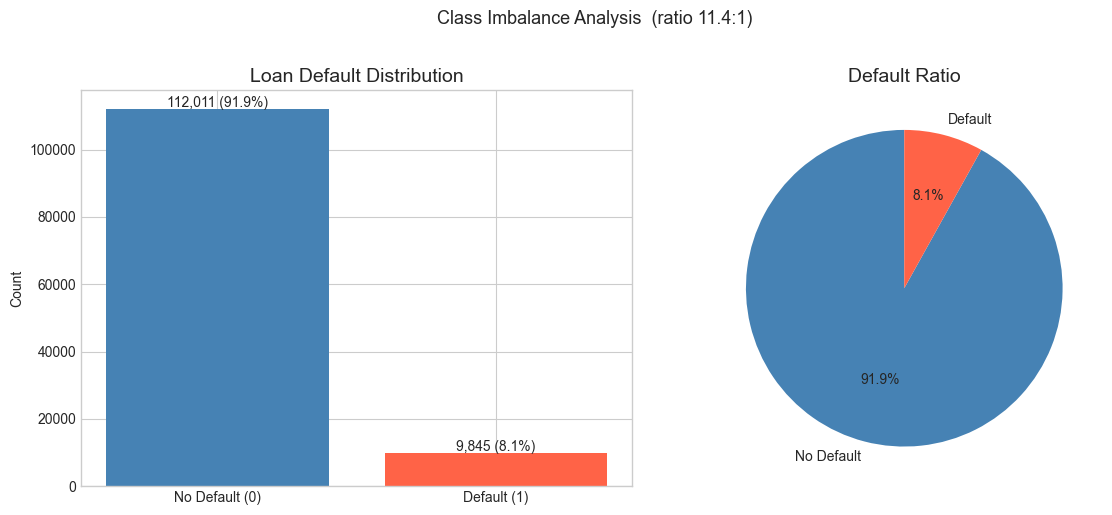

Class imbalance ratio: 11.38:1


In [ ]:
default_counts = df['Default'].value_counts().sort_index()  # index 0 then 1
n_no_default = default_counts.get(0, 0)
n_default    = default_counts.get(1, 0)
imbalance_ratio = n_no_default / n_default if n_default > 0 else float('inf')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['No Default (0)', 'Default (1)'],
            [n_no_default, n_default],
            color=['steelblue', 'tomato'])
axes[0].set_title('Loan Default Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate([n_no_default, n_default]):
    axes[0].text(i, v + 500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie([n_no_default, n_default],
            labels=['No Default', 'Default'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Default Ratio', fontsize=14)

plt.suptitle(f'Class Imbalance Analysis  (ratio {imbalance_ratio:.1f}:1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(f'Class imbalance ratio: {imbalance_ratio:.2f}:1')

## 3. Numerical Features Distribution

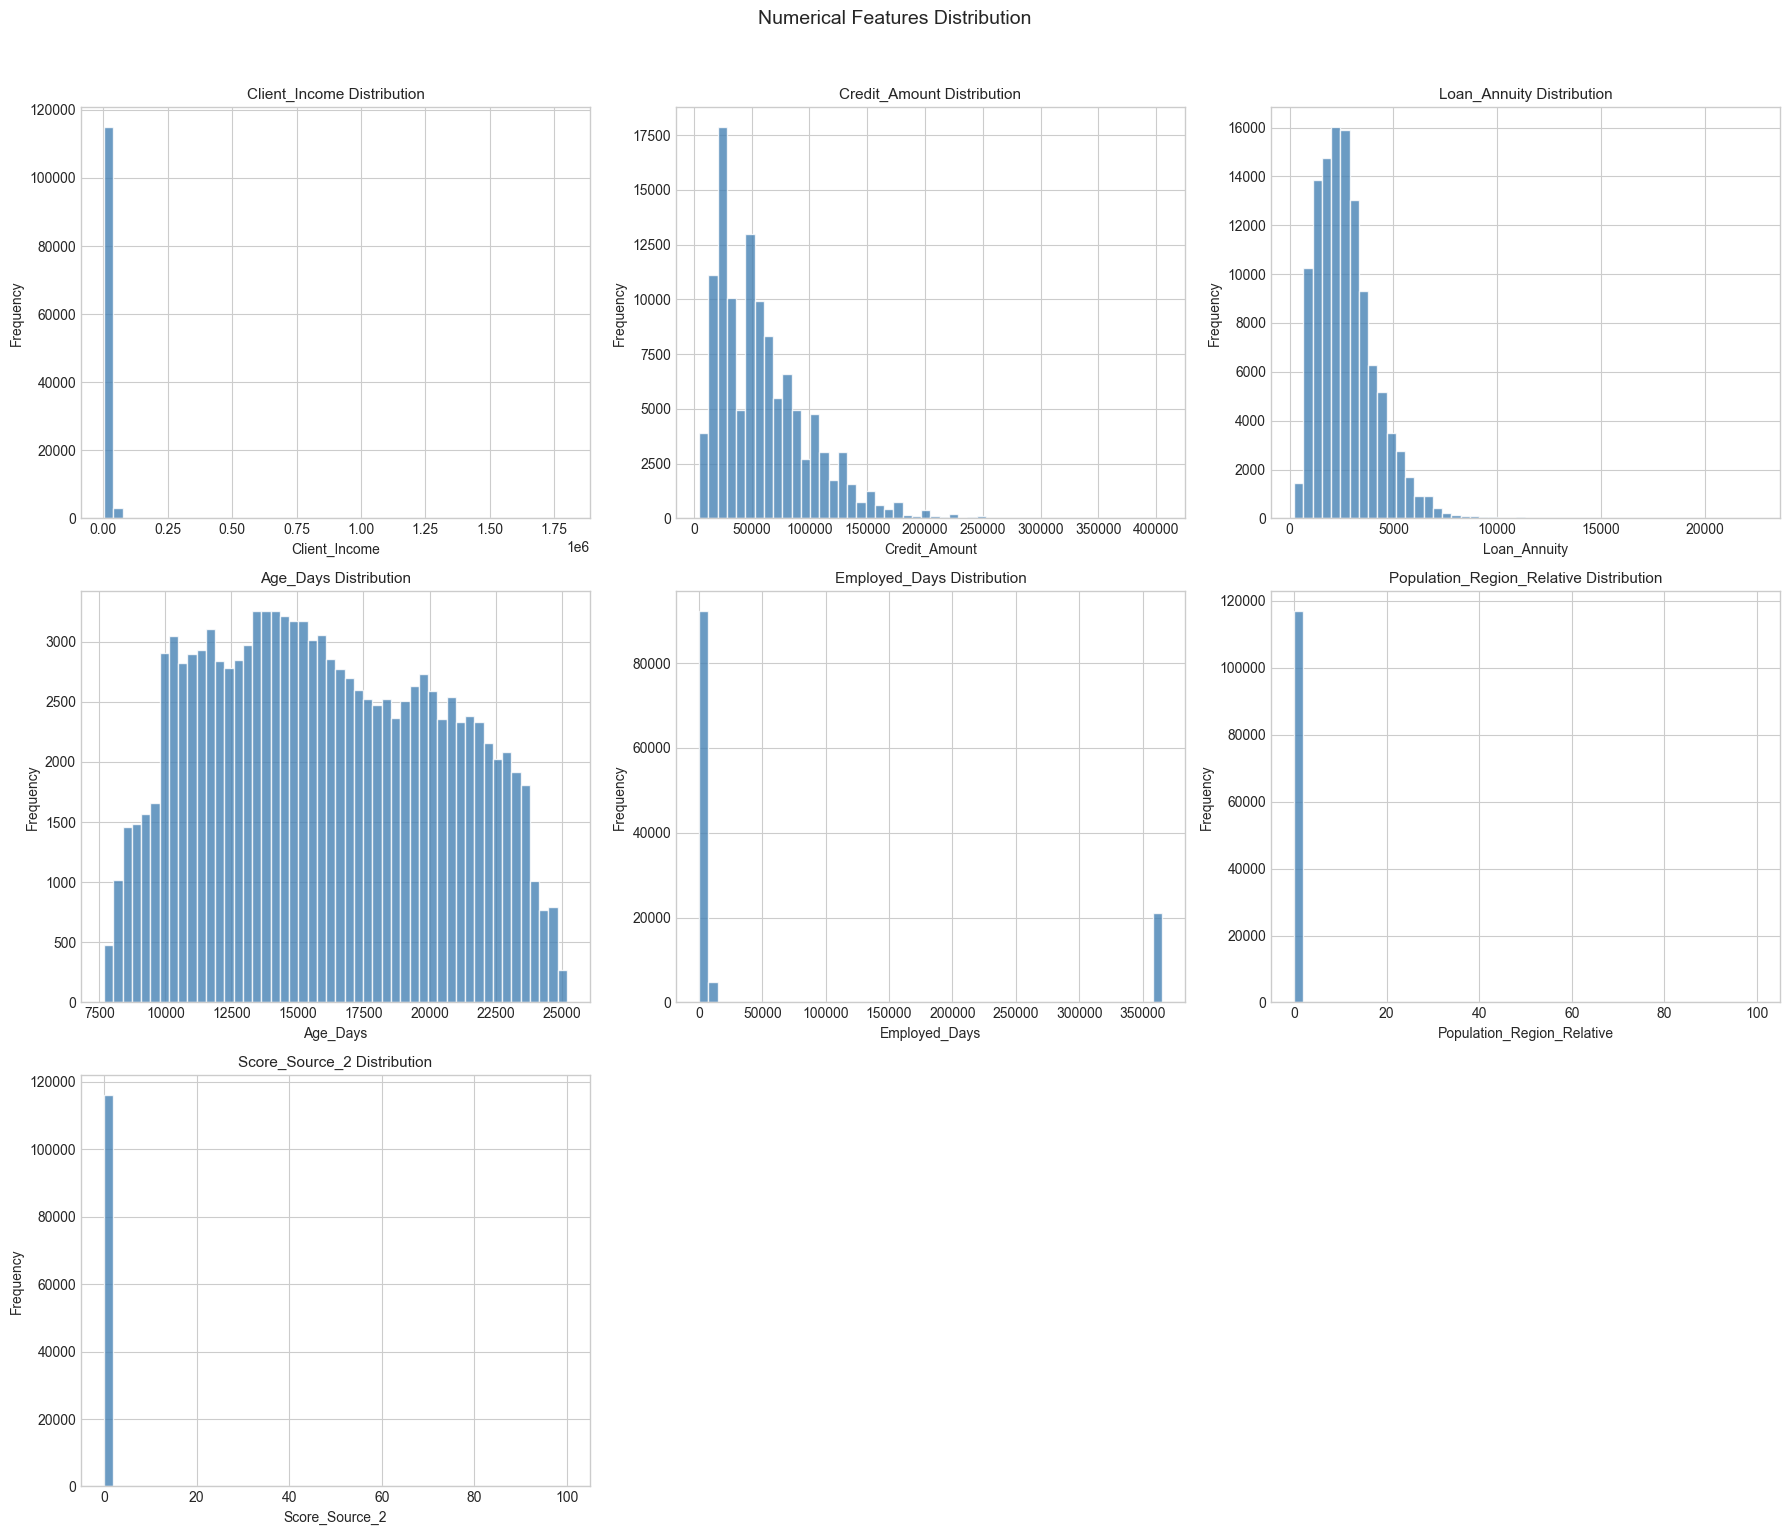

In [18]:
num_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
            'Employed_Days', 'Population_Region_Relative', 'Score_Source_2']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    col_clean = df[col].dropna()
    axes[i].hist(col_clean, bins=50, edgecolor='white', color='steelblue', alpha=0.8)
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Features Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

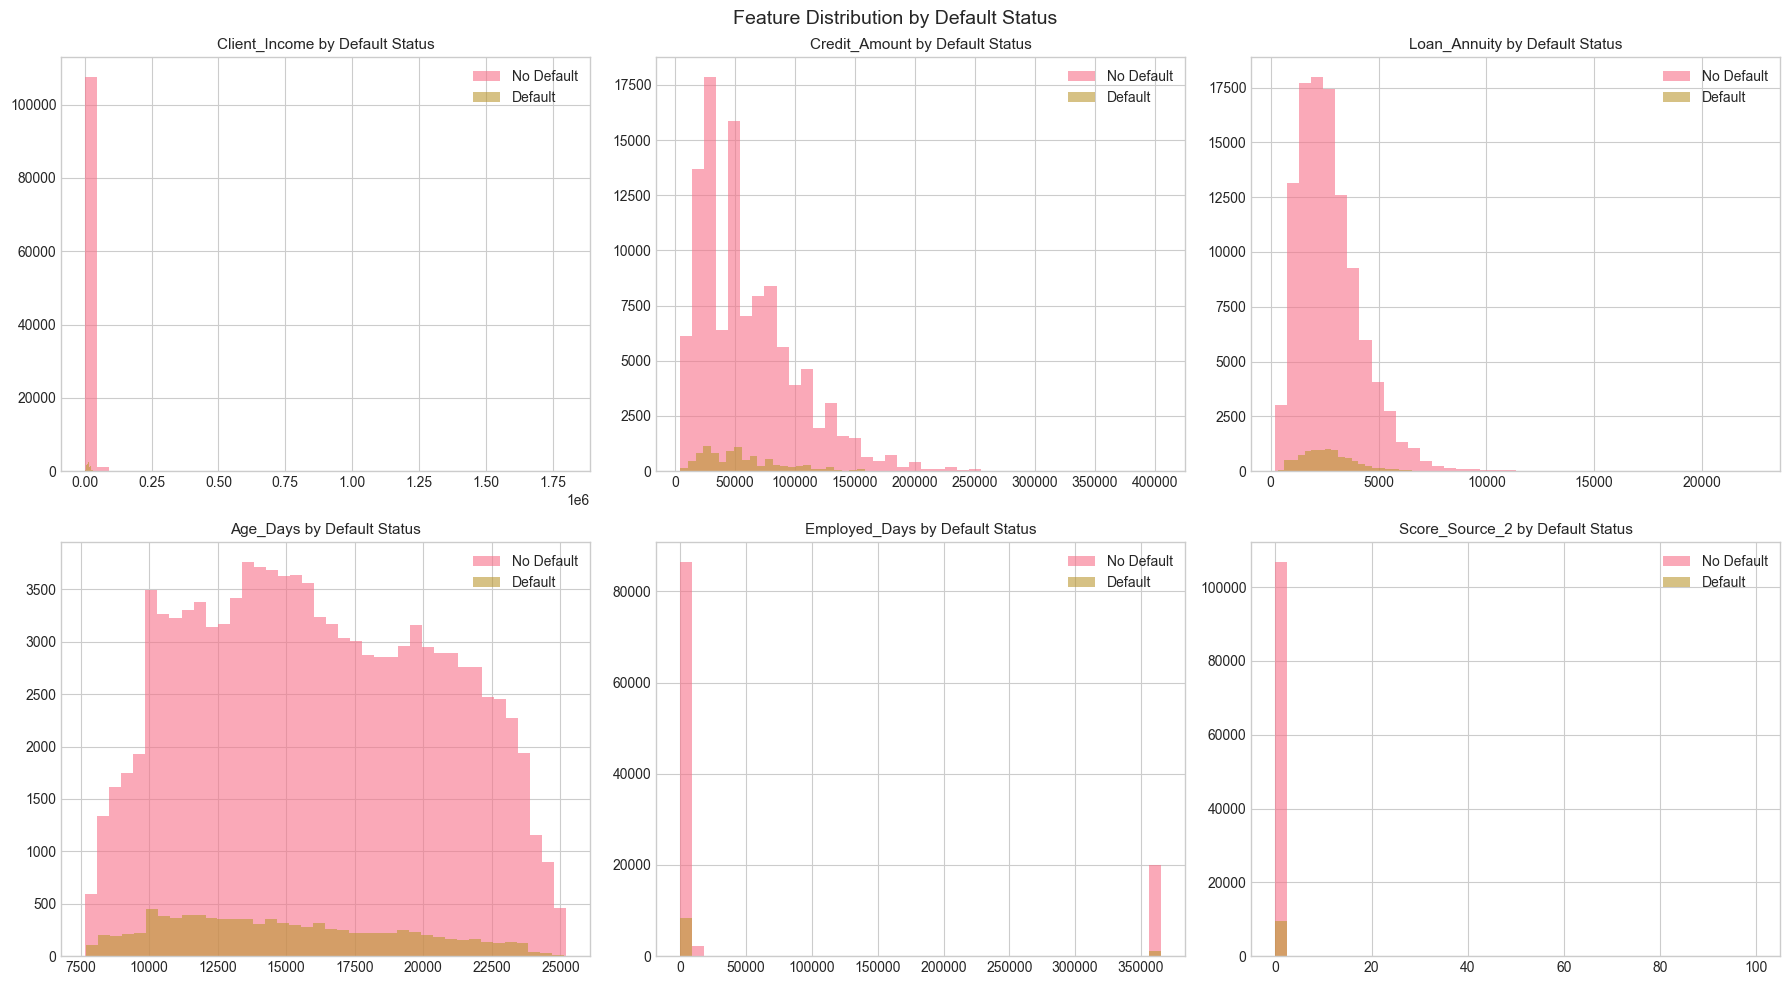

In [19]:
# Distribution by Default status
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

dist_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity',
             'Age_Days', 'Employed_Days', 'Score_Source_2']

for i, col in enumerate(dist_cols):
    for label, grp in df.groupby('Default'):
        grp[col].dropna().hist(
            bins=40, alpha=0.6, ax=axes[i],
            label='Default' if label == 1 else 'No Default'
        )
    axes[i].set_title(f'{col} by Default Status', fontsize=11)
    axes[i].legend()

plt.suptitle('Feature Distribution by Default Status', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Categorical Features Analysis

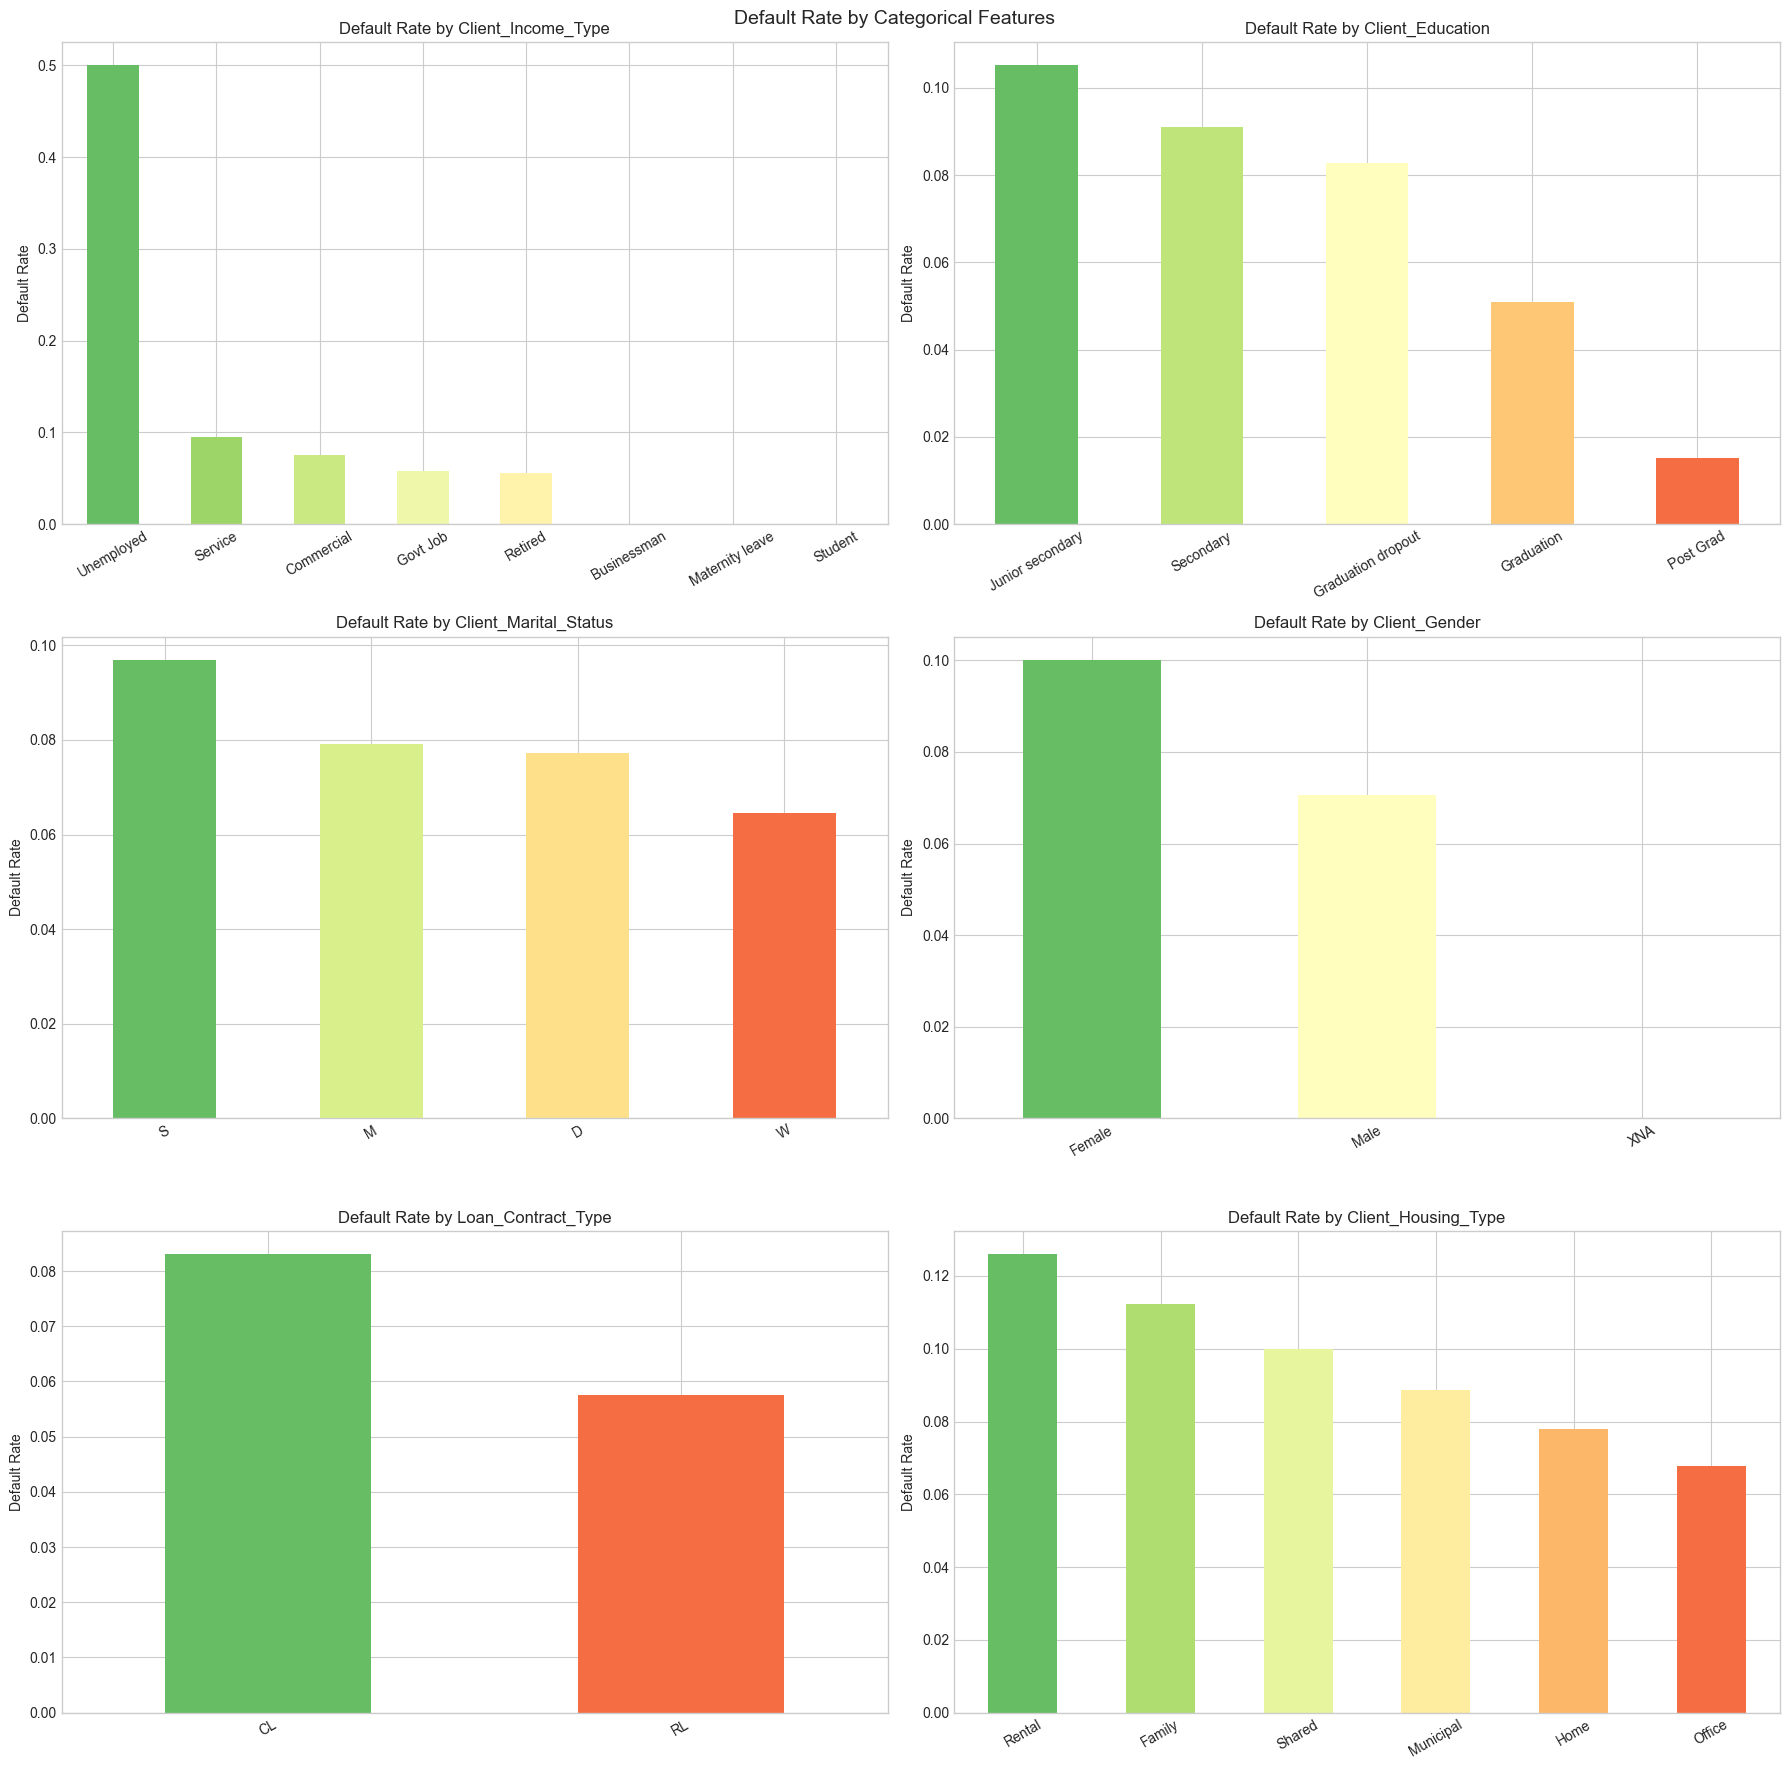

In [20]:
cat_cols = ['Client_Income_Type', 'Client_Education', 'Client_Marital_Status',
            'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['Default'].mean().sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(default_rate)))
    default_rate.plot(kind='bar', ax=axes[i], color=colors)
    axes[i].set_title(f'Default Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Default Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Outlier Detection

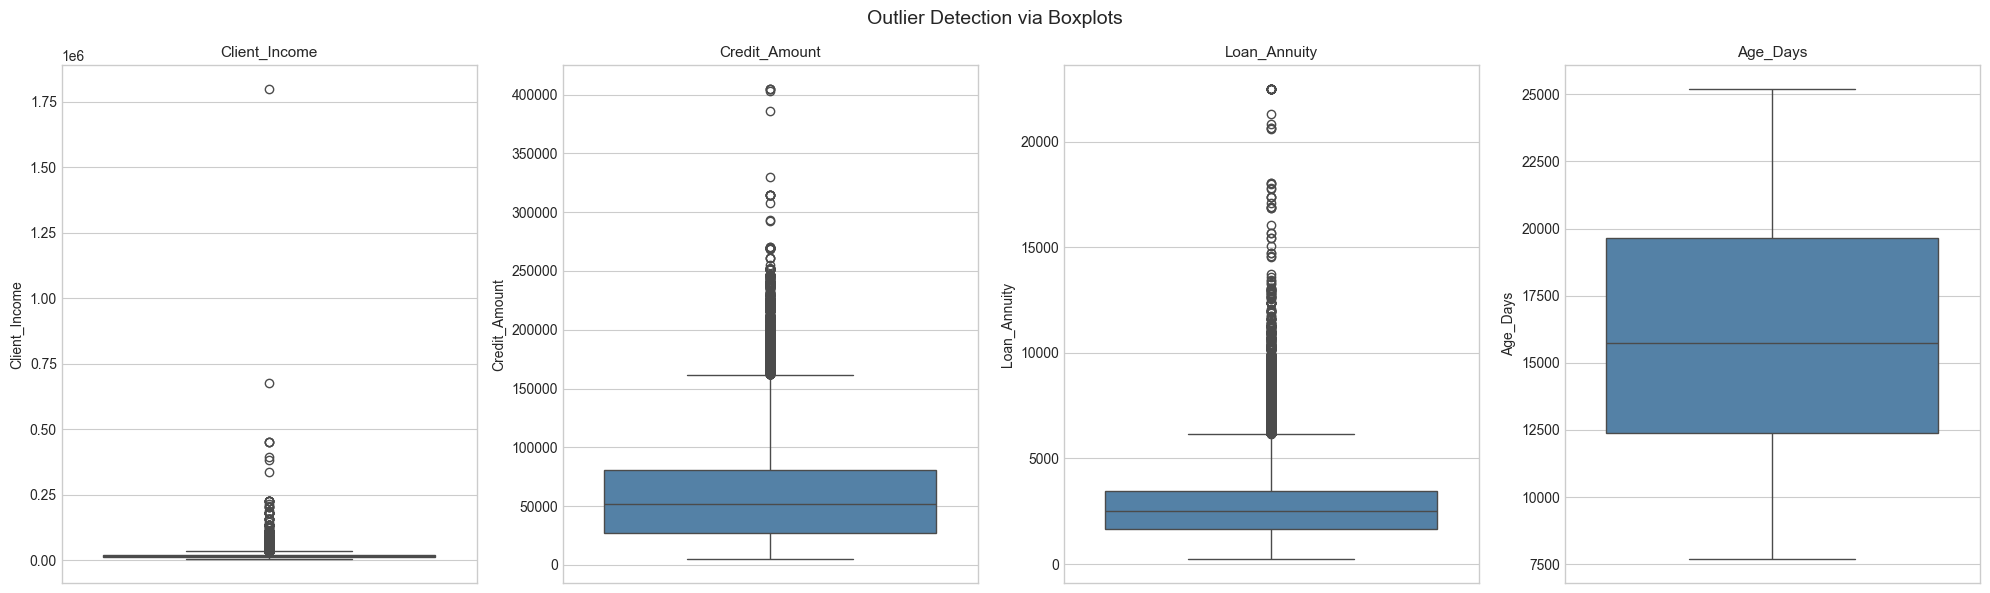

=== Outlier Counts (IQR method) ===
  Client_Income: 5,392 outliers (4.56%)
  Credit_Amount: 2,567 outliers (2.17%)
  Loan_Annuity: 2,894 outliers (2.47%)
  Age_Days: 0 outliers (0.00%)


In [ ]:
num_features = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days']
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Outlier Detection via Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

# IQR outlier counts
print('=== Outlier Counts (IQR method) ===')
for col in num_features:
    col_clean = df[col].dropna()
    Q1, Q3 = col_clean.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((col_clean < Q1 - 1.5 * IQR) | (col_clean > Q3 + 1.5 * IQR)).sum()
    print(f'  {col}: {outliers:,} outliers ({outliers / len(col_clean) * 100:.2f}%)')

## 6. Correlation Analysis

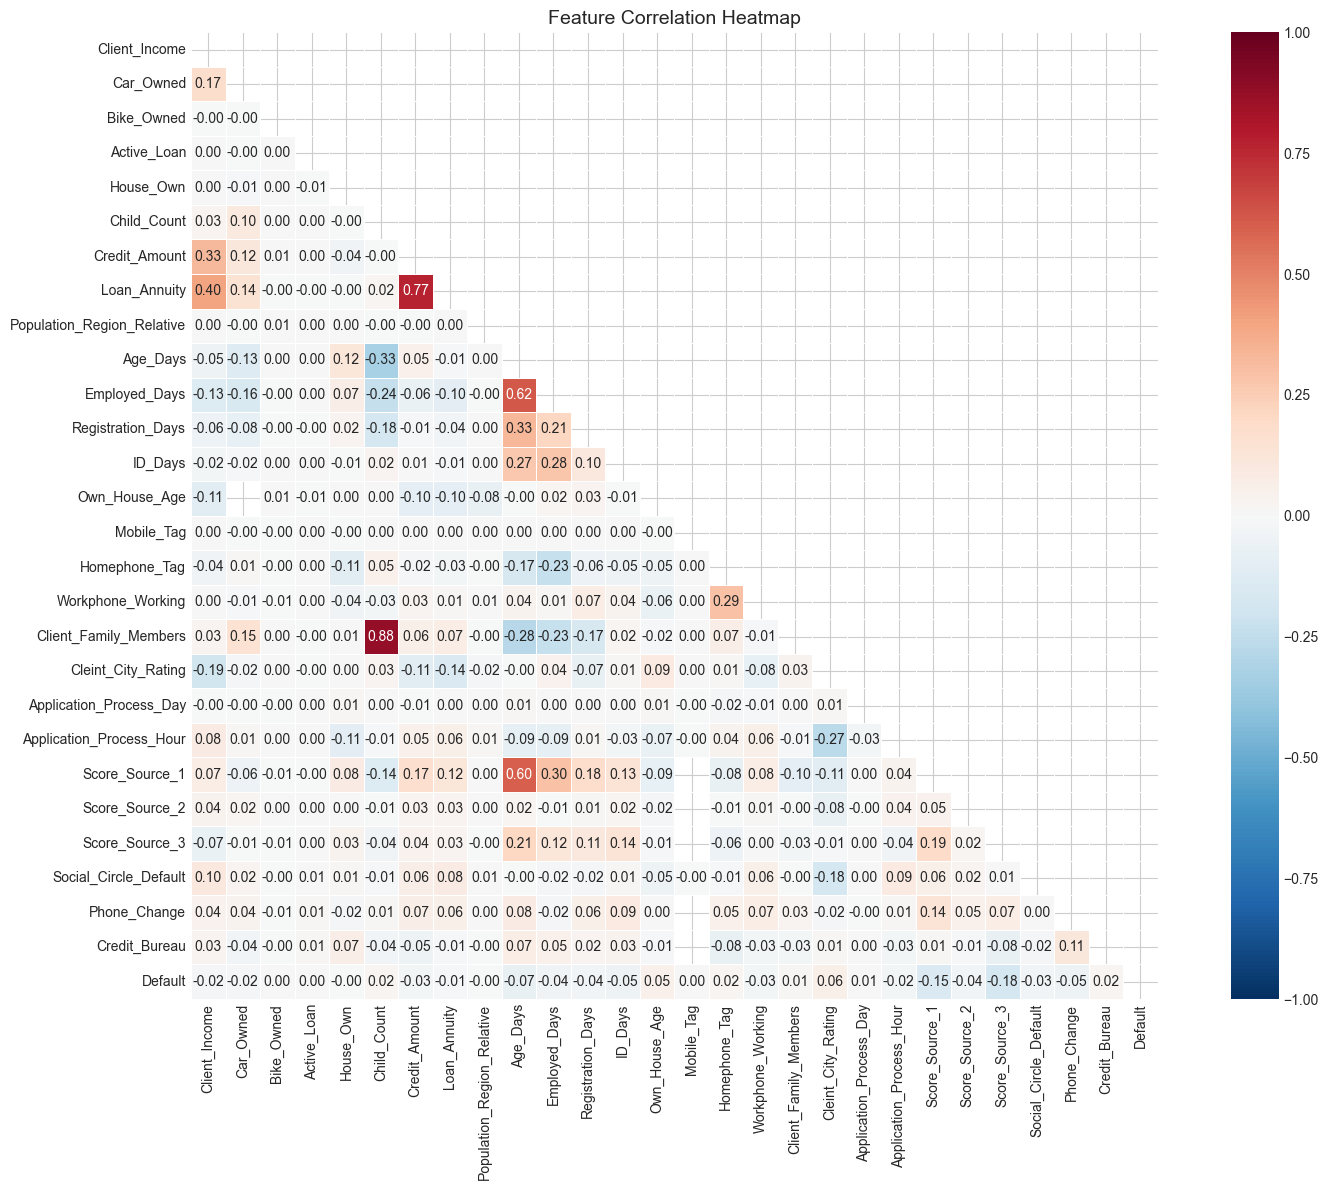

=== Top Correlations with Default ===
Cleint_City_Rating            0.058857
Own_House_Age                 0.047513
Homephone_Tag                 0.021593
Credit_Bureau                 0.020001
Child_Count                   0.019687
Client_Family_Members         0.011110
Application_Process_Day       0.005693
Mobile_Tag                    0.000849
Bike_Owned                    0.000431
Active_Loan                   0.000240
House_Own                    -0.001011
Population_Region_Relative   -0.002395
Loan_Annuity                 -0.012109
Client_Income                -0.021516
Car_Owned                    -0.023221
Application_Process_Hour     -0.023589
Workphone_Working            -0.025682
Credit_Amount                -0.031049
Social_Circle_Default        -0.032631
Score_Source_2               -0.038085
Registration_Days            -0.038524
Employed_Days                -0.044861
ID_Days                      -0.054089
Phone_Change                 -0.054591
Age_Days                  

In [ ]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')
corr_matrix = num_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with Default
print('=== Top Correlations with Default ===')
target_corr = corr_matrix['Default'].drop('Default').sort_values(ascending=False)
print(target_corr.to_string())

## 7. Feature Engineering Preview

In [ ]:
df_eng = df.copy()


df_eng['Age_Years']       = (df_eng['Age_Days'].abs() / 365).round(1)
df_eng['Employed_Years']  = df_eng['Employed_Days'].apply(
    lambda x: round(abs(x) / 365, 1) if pd.notna(x) and x != 365243 else np.nan
)
df_eng['Income_to_Credit']  = df_eng['Client_Income']  / (df_eng['Credit_Amount'].replace(0, np.nan))
df_eng['Annuity_to_Income'] = df_eng['Loan_Annuity']   / (df_eng['Client_Income'].replace(0, np.nan))
df_eng['Credit_to_Annuity'] = df_eng['Credit_Amount']  / (df_eng['Loan_Annuity'].replace(0, np.nan))
df_eng['Employment_to_Age'] = df_eng['Employed_Years'] / (df_eng['Age_Years'].replace(0, np.nan))
df_eng['Family_per_Income'] = df_eng['Client_Family_Members'] / (df_eng['Client_Income'].replace(0, np.nan))

new_features = [
    'Age_Years', 'Employed_Years', 'Income_to_Credit',
    'Annuity_to_Income', 'Credit_to_Annuity', 'Employment_to_Age', 'Family_per_Income'
]

print('=== New Engineered Features — Summary ===')
print(df_eng[new_features].describe().round(4))

print('\n=== Correlation with Default ===')
for feat in new_features:
    corr = df_eng[feat].corr(df_eng['Default'])
    print(f'  {feat:25s}: {corr:+.4f}')

=== New Engineered Features — Summary ===
         Age_Years  Employed_Years  Income_to_Credit  Annuity_to_Income  \
count  118239.0000      97092.0000       114708.0000        113566.0000   
mean       43.9107          6.5195            0.3978             0.1816   
std        11.9625          6.3758            0.3445             0.0949   
min        21.0000          0.0000            0.0203             0.0038   
25%        34.0000          2.1000            0.1933             0.1152   
50%        43.1000          4.5000            0.3048             0.1638   
75%        53.9000          8.7000            0.4936             0.2300   
max        69.0000         48.1000           26.6668             1.5706   

       Credit_to_Annuity  Employment_to_Age  Family_per_Income  
count        113538.0000         94213.0000        115909.0000  
mean             21.5970             0.1566             0.0002  
std               7.8253             0.1332             0.0001  
min               8.03

## 8. Missing Value Heatmap

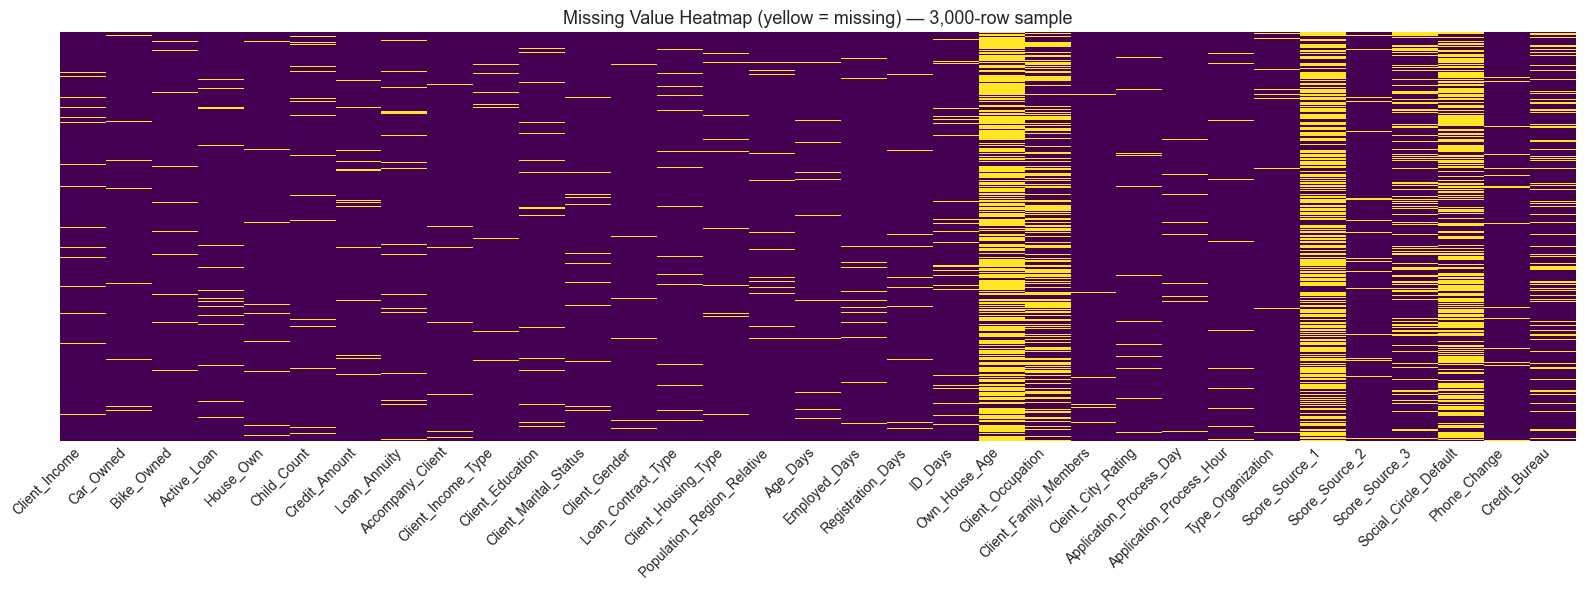

In [ ]:
sample = df.sample(min(3000, len(df)), random_state=42)

# Only show columns that have at least one missing value
cols_with_na = sample.columns[sample.isnull().any()].tolist()

plt.figure(figsize=(16, 6))
sns.heatmap(
    sample[cols_with_na].isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.title('Missing Value Heatmap (yellow = missing) — 3,000-row sample', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Binary Features Analysis

=== Default Rate by Binary Feature ===
                   Default_Rate_0  Default_Rate_1    Diff
Feature                                                  
Mobile_Tag                 0.0000          0.0808  0.0808
Homephone_Tag              0.0778          0.0925  0.0147
Bike_Owned                 0.0804          0.0806  0.0002
Active_Loan                0.0807          0.0808  0.0001
House_Own                  0.0811          0.0805 -0.0006
Car_Owned                  0.0854          0.0721 -0.0133
Workphone_Working          0.0852          0.0696 -0.0156


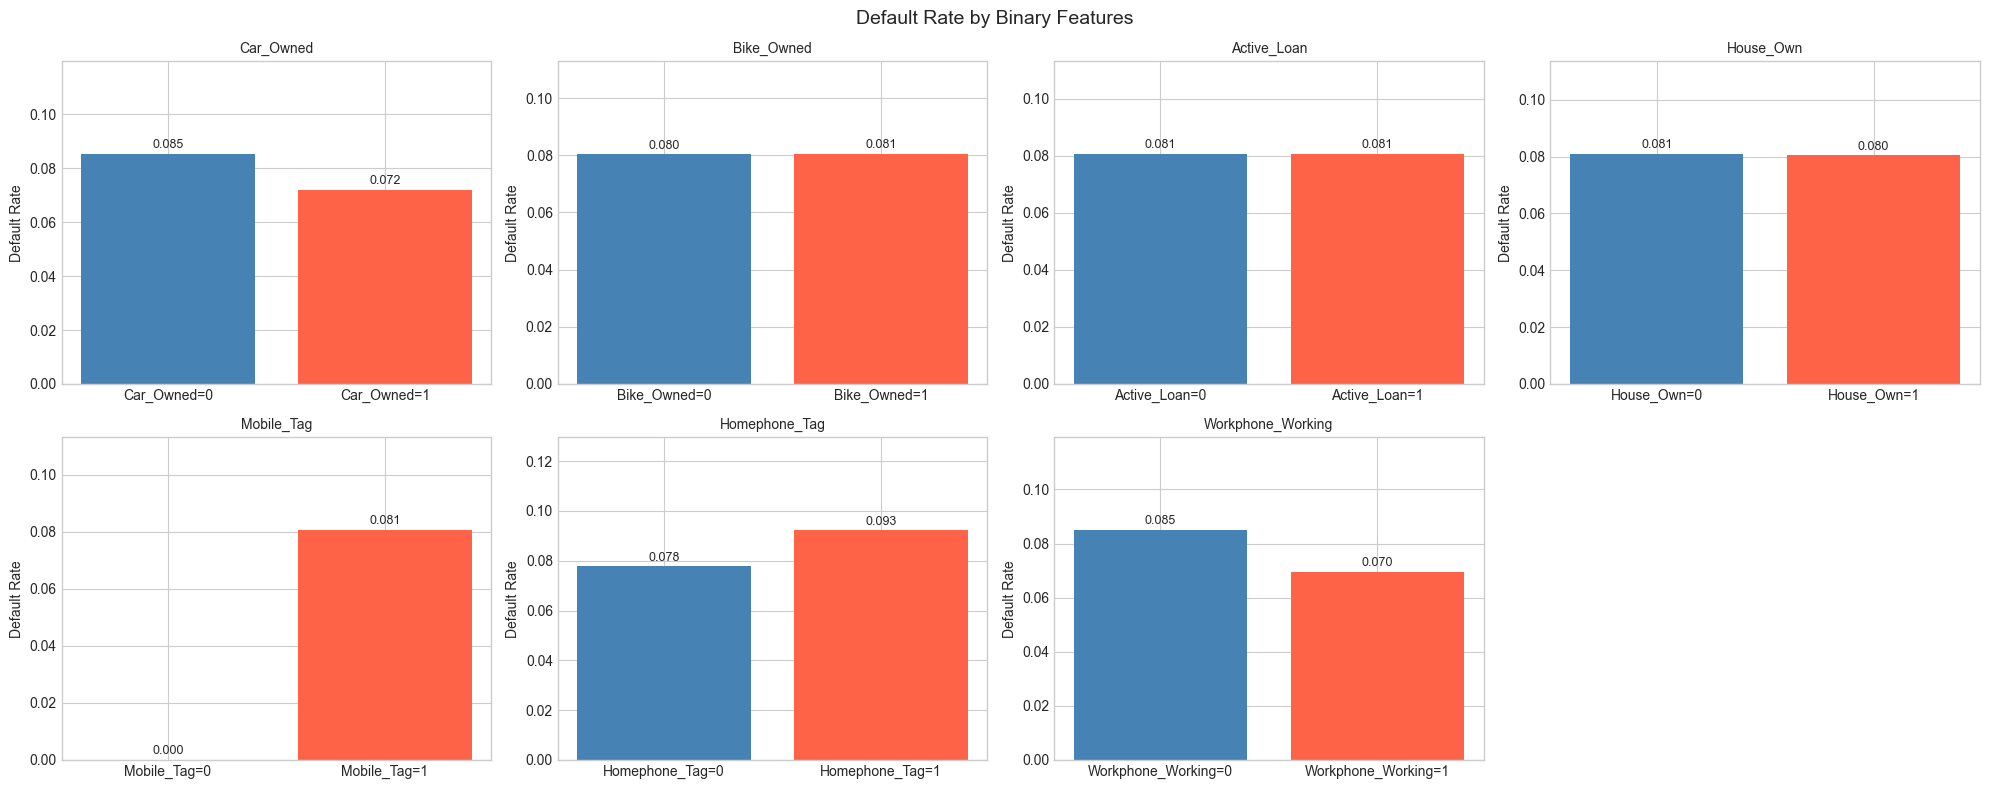

In [ ]:
binary_cols = ['Car_Owned', 'Bike_Owned', 'Active_Loan', 'House_Own',
               'Mobile_Tag', 'Homephone_Tag', 'Workphone_Working']

# Default rate per binary value
print('=== Default Rate by Binary Feature ===')
results = []
for col in binary_cols:
    rate_0 = df[df[col] == 0]['Default'].mean()
    rate_1 = df[df[col] == 1]['Default'].mean()
    results.append({'Feature': col, 'Default_Rate_0': rate_0, 'Default_Rate_1': rate_1,
                    'Diff': rate_1 - rate_0})
binary_summary = pd.DataFrame(results).set_index('Feature').round(4)
print(binary_summary.sort_values('Diff', ascending=False).to_string())

# Bar chart
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    rate = df.groupby(col)['Default'].mean()
    axes[i].bar([f'{col}=0', f'{col}=1'], rate.values, color=['steelblue', 'tomato'])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_ylim(0, rate.max() * 1.4)
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

fig.delaxes(axes[-1])  # remove the spare subplot
plt.suptitle('Default Rate by Binary Features', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary & Key Insights

In [ ]:
print('=== EDA SUMMARY ===')
print(f'Total Records   : {len(df):,}')
print(f'Total Features  : {df.shape[1]}')
print(f'Default Rate    : {df["Default"].mean()*100:.2f}%')
print(f'Imbalance Ratio : {imbalance_ratio:.1f}:1')
print(f'Columns with NaN: {(df.isnull().sum() > 0).sum()}')
print()
print('Key Findings:')
print('1. Strong class imbalance (~91.9% no-default vs ~8.1% default) — SMOTE required')
print('2. Heavy missing data: Own_House_Age (65.7%), Score_Source_1 (56.5%)')
print('3. Score_Source_2 shows the highest correlation with the Default target')
print('4. Commercial and unemployed income types have higher default rates')
print('5. Cash loans (CL) dominate over Revolving Loans (RL)')
print('6. Active_Loan=1 clients default at a noticeably higher rate')
print('7. Engineered features (Income_to_Credit, Annuity_to_Income) carry meaningful signal')
print('8. Employed_Days contains pensioner sentinel value 365243 — must be treated as NaN')

=== EDA SUMMARY ===
Total Records   : 121,856
Total Features  : 40
Default Rate    : 8.08%
Imbalance Ratio : 11.4:1
Columns with NaN: 33

Key Findings:
1. Strong class imbalance (~91.9% no-default vs ~8.1% default) — SMOTE required
2. Heavy missing data: Own_House_Age (65.7%), Score_Source_1 (56.5%)
3. Score_Source_2 shows the highest correlation with the Default target
4. Commercial and unemployed income types have higher default rates
5. Cash loans (CL) dominate over Revolving Loans (RL)
6. Active_Loan=1 clients default at a noticeably higher rate
7. Engineered features (Income_to_Credit, Annuity_to_Income) carry meaningful signal
8. Employed_Days contains pensioner sentinel value 365243 — must be treated as NaN
